In [1]:
!pip install -U fvcore

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'fvcore'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61444 sha256=e3ad2cbff22e1ebddc3e646cacdd8d143f91f782250f908e44093b10e328f62c
  Stored in directory: /home/soom/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  DEPRECATION: Building 'iopath' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replac

Unsupported operator aten::add_ encountered 58 time(s)
Unsupported operator aten::silu_ encountered 49 time(s)
Unsupported operator aten::sigmoid encountered 16 time(s)
Unsupported operator aten::mul encountered 25 time(s)
Unsupported operator aten::bernoulli_ encountered 9 time(s)
Unsupported operator aten::div_ encountered 9 time(s)
Unsupported operator aten::dropout_ encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
accuracy, f1_score, loss_fn, model.features.1.0.stochastic_depth, model.features.2.0.stochastic_depth, model.features.3.0.stochastic_depth, model.features.4.0.stochastic_depth, model.features.5.0.stochastic_depth, model.features.6.0.stochastic_depth, model.features.7.0.stochastic_de

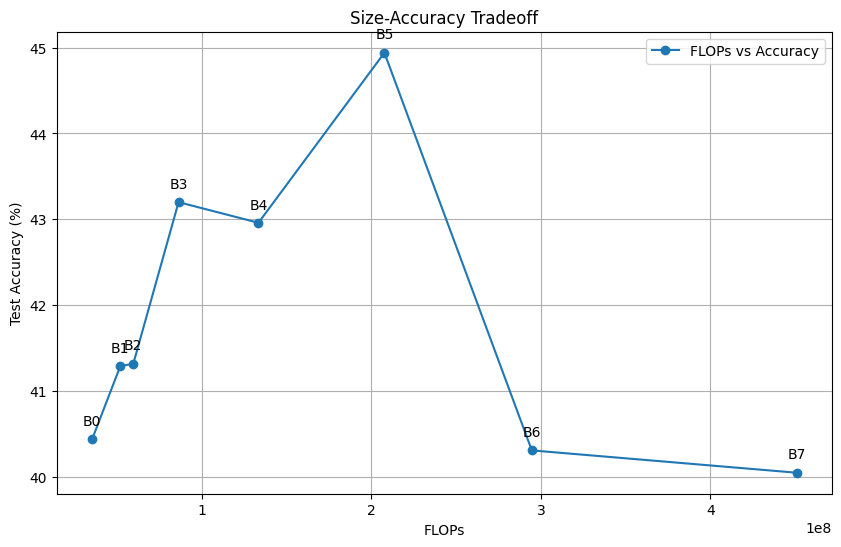

In [15]:
import matplotlib.pyplot as plt
import torch
from fvcore.nn import FlopCountAnalysis

from src.network import SimpleClassifier

flops = []
input_img = torch.randn(1, 3, 64, 64)

for num in range(8):
    model = SimpleClassifier(
        model_name=f'efficientnet_b{num}',
        num_classes=200,
    )
    f = FlopCountAnalysis(model, input_img)
    flops.append(f.total())
    
accuracies = [      # values from [test.py] results
    0.4044,
    0.4129,
    0.4132,
    0.4320,
    0.4296,
    0.4494,
    0.4031,
    0.4005,
]
accuracies = [x * 100 for x in accuracies]

plt.figure(figsize=(10, 6))
plt.plot(flops, accuracies, marker='o', label='FLOPs vs Accuracy')
for i in range(len(flops)):
    plt.annotate(f'B{i}', (flops[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlabel('FLOPs')
plt.ylabel('Test Accuracy (%)')
plt.title('Size-Accuracy Tradeoff')
plt.legend()
plt.grid(True)
plt.show()

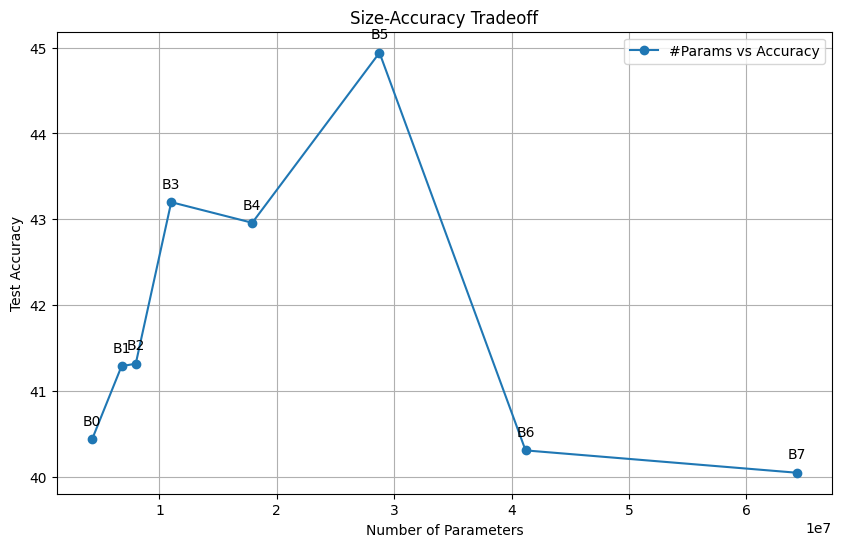

In [17]:
params = []
for num in range(8):
    model = SimpleClassifier(
        model_name=f'efficientnet_b{num}',
        num_classes=200,
    )
    param = sum(p.numel() for p in model.parameters() if p.requires_grad)
    params.append(param)

plt.figure(figsize=(10, 6))
plt.plot(params, accuracies, marker='o', label='#Params vs Accuracy')
for i in range(len(params)):
    plt.annotate(f'B{i}', (params[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlabel('Number of Parameters')
plt.ylabel('Test Accuracy')
plt.title('Size-Accuracy Tradeoff')
plt.legend()
plt.grid(True)
plt.show()